In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os
print(os.getenv("TAVILY_API_KEY"))

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


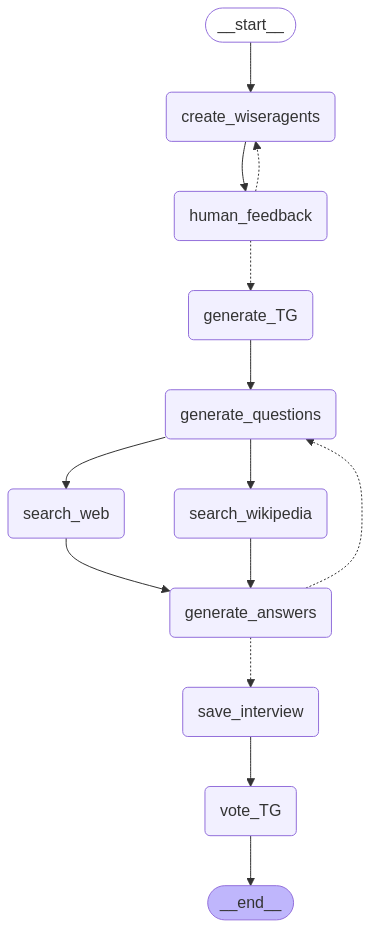

In [3]:
from graph import graph
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
from graph import graph
from state import get_current_state

# Cell 3: Execute the graph for generating WiserAgents
thread = {"configurable": {"thread_id": "1"}}

current_state = get_current_state()

for event in graph.stream(current_state, thread, stream_mode="values"):
    # WiserAgents printing 
    print("Generating WiserAgents...\n")
    state_wiseragents = event.get("wiseragents", None)
    if not state_wiseragents:
        continue    
    # Handle case if it's a tuple
    if isinstance(state_wiseragents, tuple):
        state_wiseragents = state_wiseragents[0]
    # If it's a wrapper (Pydantic model), get the list
    if hasattr(state_wiseragents, "wiseragents"):
        state_wiseragents = state_wiseragents.wiseragents
    # Now it should be a list of agents
    for agent in state_wiseragents:
        print(f"Name: {agent.name}")
        print(f"Domain Expertise: {agent.domain_expertise}")
        print(f"Description: {agent.description}")
        print(f"Wisdom Score: {agent.WS}")
        print(f"Preferred LLM: {agent.preferred_llm}")
        print("-" * 50)
    print("WiserAgents generated:")

    # TG printing
    tg_candidates = event.get("tg_candidates", [])
    print("Generating TGs...\n")

    for candidate in tg_candidates:
        agent = candidate.get("agent")
        tg = candidate.get("task_graph")

        if not tg:
            continue

        print(f"\nProposed by: {agent}")
        
        tg_dict = {
            "tasks": tg.tasks if hasattr(tg, "tasks") else {},
            "orders": tg.orders if hasattr(tg, "orders") else [],
        }

        import json
        print(json.dumps(tg_dict, indent=2))
        print("-" * 50)

    print("Task Graphs generated.\n")
    print ("Conducting interview...\n")
    print ("Generating questions...\n")
    # here the questions generation printing

Generating WiserAgents...

Generating WiserAgents...

Name: AIAttackTechniquesAgent
Domain Expertise: Offensive AI
Description: Specializes in understanding and predicting AI-driven cyber attacks.
Wisdom Score: 50
Preferred LLM: qwen2.5:latest
--------------------------------------------------
Name: AIDefenseMechanismsAgent
Domain Expertise: Defensive AI
Description: Focuses on developing and implementing AI-based security measures to protect websites from cyber threats.
Wisdom Score: 50
Preferred LLM: qwen2.5:latest
--------------------------------------------------
Name: EthicsInAIsecurityAgent
Domain Expertise: Ethics in AI Security
Description: Ensures that the use of AI in cybersecurity aligns with ethical standards and legal regulations.
Wisdom Score: 50
Preferred LLM: qwen2.5:latest
--------------------------------------------------
WiserAgents generated:
Generating TGs...

Task Graphs generated.

Conducting interview...

Generating questions...

>> Awaiting human feedback on Wi

KeyError: 'tg_candidates'

In [5]:
# Get state and look at next node
state = graph.get_state(thread)
print(state.next)

('search_wikipedia',)


In [7]:
# Continue executing the graph
for event in graph.stream(None, thread, stream_mode="updates"):
    node_name = next(iter(event.keys()))
    print("-- Executed node:", node_name)

# Get the final state of the graph
final_state = graph.get_state(thread)
print("\nFinal State:")
print(final_state)

KeyError: '"from"'

In [ ]:
# final chosen TG
final_tg = final_state.values.get('tg_chosen')
if final_tg:
    print("\nChosen TG:")
    print(final_tg.to_json())
else:
    print("\nNo TG chosen.")